# MMToM-QA Accuracy

200  86.5% results-0725-mmtom-seed2
200  95.7% results-0727-mmtom-seed013
 90  87.8% results-gemini
199  83.4% results-deepseek
 75  81.3% results-qwen


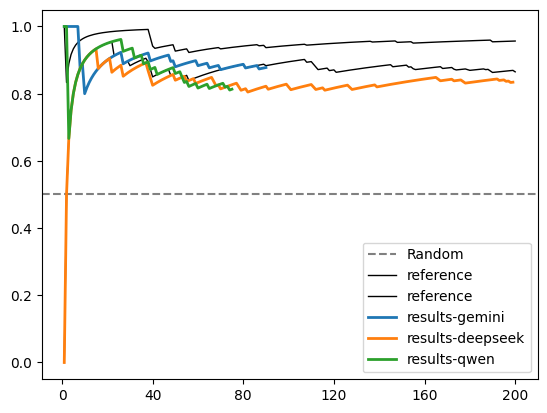

In [35]:
import matplotlib.pyplot as plt
from pathlib import Path
import json


def get_and_plot_accs(exp_id, datum_range, reference=False):
    accs = []
    for datum_id in range(*datum_range):
        acc = []
        for path in (Path(exp_id) / "metrics").glob(
            f"automated_MMToM-QA_{datum_id}_back1_reduce1_seed*_metrics.json"
        ):
            with path.open("r") as f:
                acc.append(json.load(f)["Correctness"])
        if len(acc) > 0:
            accs.append(sum(acc) / len(acc))
    print(
        f"{len(accs):>3}",
        f"{sum(accs) / len(accs):>6.1%}",
        f"{exp_id}",
    )
    if exp_id.count("-") == 0:
        exp_id = "----running"
    plt.plot(
        range(1, len(accs) + 1),
        [sum(accs[:i]) / len(accs[:i]) for i in range(1, len(accs) + 1)],
        # label="reference" if reference else "-".join(exp_id.split("-")[4:]),
        label="reference" if reference else exp_id,
        color="black" if reference else None,
        linewidth=1 if reference else 2,
    )
    return accs


# START_ID, NUM_SAMPLES, STEP = 550, 50, 10
# START_ID, NUM_SAMPLES, STEP = 0, 600, 100
# START_ID, NUM_SAMPLES, STEP = 0, 100, 20
# START_ID, NUM_SAMPLES, STEP = 100, 200, 20
START_ID, NUM_SAMPLES, STEP = 0, 200, 40

datum_range = (START_ID, START_ID + NUM_SAMPLES)
plt.xticks(
    range(0, NUM_SAMPLES + 1, STEP),
    range(START_ID, START_ID + NUM_SAMPLES + 1, STEP),
)
plt.axhline(y=0.5, color="gray", linestyle="--", label="Random")
# * reference
get_and_plot_accs("results-0725-mmtom-seed2", datum_range, True)
get_and_plot_accs("results-0727-mmtom-seed013", datum_range, True)
# * new model, only replace logprob (550 - 600)
# get_and_plot_accs("results-0728-mmtom-seed0-logprobs-qwen3-32b", datum_range)
# get_and_plot_accs("results-0729-mmtom-seed0-logprobs-qwen3-235b", datum_range)
# get_and_plot_accs("results-0729-mmtom-seed0-logprobs-dsv3", datum_range)
# * new model, fully replaced (0 - 600)
get_and_plot_accs("results-gemini", datum_range)
get_and_plot_accs("results-deepseek", datum_range)
get_and_plot_accs("results-qwen", datum_range)
plt.legend(loc="lower right")
plt.show()